# 🌾 Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1, 2026–2027 | Major Project**

## Central Question

How does agricultural performance vary across seasons, and what environmental, resource, production, and economic factors are associated with those differences?

## Problem Statement

Agricultural performance can change with seasonal environmental conditions, farming practices, resource availability, and economic factors. This project analyzes the available agricultural records to identify meaningful seasonal patterns, relationships, differences, and variations rather than treating the dataset as a generic collection of charts.

## Analytical Story

**Season → Environment → Resources → Yield and Production → Cost, Revenue and Profit → Water Efficiency → Disease and Pest Risk → Recommendations**

> **Notebook principle:** Each major analysis is tied to a question, supported by evidence from the dataset, and followed by a concise interpretation.

## 🎯 Project Objectives

- Explore and understand the agricultural dataset.
- Clean and prepare the data using a reproducible process.
- Compare agricultural performance across seasons.
- Examine environmental and resource differences.
- Analyze production, revenue, cost, and profitability.
- Evaluate water usage and water efficiency.
- Investigate relationships and correlations among key variables.
- Apply statistical testing where it is justified.
- Convert analytical results into evidence-based findings.
- Develop practical, data-supported recommendations.

**Reading guide:** Each major section follows **Analytical Question → Analysis → Output or Visualization → Key Finding → Interpretation**.

## Analytical Question Map

The project brief encourages student-developed questions about seasonal performance, changing characteristics, resource usage, environmental relationships, economic outcomes, regional consistency, unusual patterns, evidence-based conclusions, and planning recommendations.

<details>
<summary><b>25-question working checklist</b></summary>

1. How does agricultural performance vary across seasons?  
2. Which season has the highest or lowest average yield?  
3. How does production vary across seasons?  
4. How does profitability vary across seasons?  
5. How do revenue and total cost differ between seasons?  
6. How do rainfall, temperature, humidity, and sunlight vary across seasons?  
7. How does soil moisture vary across seasons?  
8. How does irrigation method distribution vary across seasons?  
9. How does water usage vary across seasons?  
10. How does water efficiency vary across seasons?  
11. How does disease and pest risk vary across seasons?  
12. Which crops perform best in each season?  
13. Are some crops particularly associated with certain seasons?  
14. How do fertilizer, pesticide, and nutrient usage differ across seasons?  
15. Is there a relationship between environmental conditions and yield?  
16. Is there a relationship between water usage and yield?  
17. Is there a relationship between water efficiency and profitability or yield?  
18. Is there a relationship between farm area and production?  
19. Which factors have the strongest correlation with yield?  
20. Which factors have the strongest relationship with profit?  
21. Are there meaningful differences between states and districts?  
22. Are some seasonal patterns consistent across geographical areas?  
23. Are there unusual or unexpected observations?  
24. What are the most important evidence-based findings?  
25. What practical recommendations can reasonably be derived?

</details>

**Coverage note:** Questions requiring a deeper geographic or anomaly check are handled in the targeted analysis section. Conclusions are drawn only where the dataset supports them.

In [68]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

working_directory = Path.cwd().resolve()
project_candidates = [
    working_directory.parent if working_directory.name.lower() == "notebooks" else working_directory,
    working_directory,
]

for candidate in project_candidates:
    if (candidate / "data").is_dir() and (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the project root containing data/ and src/.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_cleaning import clean_data
from src.analysis import one_way_anova, data_quality_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


**Setup note:** The notebook imports the core analysis libraries and project modules, then establishes a portable project path for the workflow.

## 1. 📊 Load Dataset

### Analytical Question

What data is available for the analysis, and what is the size of the dataset?

### Analysis

The CSV is treated as the source of truth. The raw dataset is loaded without modifying the original file.

In [69]:
data_path = PROJECT_ROOT / "data" / "seasonal_agriculture_performance_dataset.csv"
raw_df = pd.read_csv(data_path)

print("Dataset shape:", raw_df.shape)
display(raw_df.head())


Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### Key Finding

The dataset contains **4,000 records and 28 variables**, providing a broad basis for seasonal agricultural performance analysis.

**Interpretation:** The dataset has enough observations and variables to support comparisons across seasons, crops, resources, and economic outcomes.

## 2. 🔎 Initial Data Inspection

### Analytical Questions

- What variables are present?
- What are their data types?
- Are there missing values?
- Are duplicate records present?
- How many unique categories are present?

### Analysis

This step establishes the data-quality baseline before any transformation.

In [70]:
display(pd.DataFrame({
    "Column": raw_df.columns,
    "Data Type": raw_df.dtypes.astype(str).values,
    "Missing Values": raw_df.isna().sum().values,
    "Unique Values": [raw_df[c].nunique() for c in raw_df.columns]
}))

print("Duplicate rows:", raw_df.duplicated().sum())


,Column,Data Type,Missing Values,Unique Values
0,Farm_ID,str,0,4000
1,State,str,0,8
2,District,str,0,10
3,Crop,str,0,8
4,Season,str,0,3
5,Farm_Area_Hectares,float64,0,1370
6,Rainfall_mm,float64,48,3256
7,Avg_Temperature_C,float64,0,204
8,Humidity_pct,float64,0,573
9,Sunlight_Hours_Day,float64,0,71


Duplicate rows: 0


### Key Finding

- The raw dataset contains **0 duplicate rows**.
- Missing values are concentrated in a small number of numerical fields.

**Interpretation:** The data-quality baseline is suitable for the reproducible cleaning step that follows.

## 3. 🧹 Data Cleaning and Quality Checks

### Analytical Questions

- Are there missing values requiring treatment?
- Are duplicate records present?
- Are important derived values internally consistent?
- What changes are made during cleaning, and why?

### Analysis

The cleaning process treats unusual observations as data to investigate rather than removing them automatically. Each treatment has a reproducible analytical reason, and the raw CSV remains unchanged.

In [71]:
df, cleaning_changes = clean_data(raw_df)

print("Cleaning actions:")
for change in cleaning_changes:
    print("-", change)

print("\nMissing values after cleaning:")
display(df.isna().sum()[df.isna().sum() > 0])

quality = data_quality_report(df)
quality


Cleaning actions:
- Filled 48 missing Rainfall_mm values using season-level median
- Filled 40 missing Soil_Moisture_pct values using season-level median
- Reconstructed 32 missing Yield_Tonnes_Ha values from Production_Tonnes / Farm_Area_Hectares

Missing values after cleaning:


Series([], dtype: int64)

{'rows': 4000,
 'columns': 28,
 'duplicates': 0,
 'missing_cells': 0,
 'revenue_profit_consistency_max_abs_error': 0.0,
 'production_yield_consistency_max_abs_error': 0.005000000000002558}

### Key Finding

- Filled **48 rainfall** values and **40 soil-moisture** values using season-level medians.
- Reconstructed **32 missing yield** values from production and farm area.
- The quality report shows **0 missing cells and 0 duplicates** after cleaning.

**Interpretation:** The cleaned dataset is complete for the planned analysis while preserving the original observations and reproducible treatment rules.

In [72]:
# Mathematical consistency checks
revenue_profit_error = np.abs(
    df["Revenue_INR"] - df["Total_Cost_INR"] - df["Profit_INR"]
).max()

production_yield_error = np.abs(
    df["Production_Tonnes"] -
    df["Farm_Area_Hectares"] * df["Yield_Tonnes_Ha"]
).max()

print("Max |Revenue - Cost - Profit| error:", revenue_profit_error)
print("Max |Production - Area × Yield| error:", production_yield_error)


Max |Revenue - Cost - Profit| error: 0
Max |Production - Area × Yield| error: 0.005000000000002558


### Key Finding

- Revenue minus cost minus profit has a maximum absolute error of **0**.
- Production and area multiplied by yield differ by only about **0.005 tonnes** at maximum.

**Interpretation:** The financial and production fields are internally consistent, subject to the expected rounding difference.

## 4. Descriptive Statistics

### Analytical Question

What does the overall numerical distribution of the cleaned dataset look like?

### Analysis

The summary statistics provide a baseline for interpreting later seasonal, crop, environmental, and economic comparisons.

In [73]:
display(df.describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,4000.0,600.71,288.43,80.00,370.42,581.00,836.12,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.0,26.50,6.70,8.00,21.70,26.40,31.20,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


### Key Finding

Across the cleaned dataset, average yield is about **5.26 t/ha**, average production is **43.25 tonnes**, and average profit is positive overall. The wide standard deviations indicate substantial variation between records.

**Interpretation:** Overall averages provide useful context, but seasonal and crop-level comparisons are needed to understand the variation.

## 5. Exploratory Data Analysis

### Analytical Questions

- How are records distributed across seasons?
- Which crops are most represented?
- How are farms distributed across states and districts?
- Which irrigation methods are most common?

### Analysis

These distributions describe the structure and representation of the dataset before comparing performance.

In [74]:
for col in ["Season", "Crop", "State", "District", "Irrigation_Method"]:
    print(f"\n{col} distribution")
    display(df[col].value_counts().rename("Count").to_frame())



Season distribution


,Count
Season,
Kharif,1779
Rabi,1627
Zaid,594



Crop distribution


,Count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



State distribution


,Count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484



District distribution


,Count
District,
Ludhiana,427
Warangal,422
Nalgonda,415
Erode,403
Rajkot,401
Krishna,393
Indore,392
Guntur,390
Raichur,386



Irrigation_Method distribution


,Count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


### Key Finding

- **Kharif** is the largest seasonal group with **1,779 records**.
- **Zaid** is the smallest seasonal group with **594 records**.
- **Rice** is the most represented crop with **690 records**.
- **Flood irrigation** is the most common method with **1,310 records**.

**Interpretation:** The category counts provide important context for interpreting later group-level comparisons.

## 6. 🌱 Seasonal Performance

### Analytical Questions

1. How does agricultural performance vary across seasons?
2. Which season has the highest and lowest average yield?
3. How does production vary across seasons?
4. How does profitability vary across seasons?
5. How do revenue and total cost differ between seasons?
6. How does water efficiency vary across seasons?
7. How does disease and pest risk vary across seasons?

### Analysis

The grouped summary compares the main performance indicators using season-level means.

In [75]:
season_means = df.groupby("Season")[[
    "Yield_Tonnes_Ha", "Production_Tonnes", "Revenue_INR",
    "Total_Cost_INR", "Profit_INR", "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]].mean().round(2)

display(season_means)


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,5.89,54.47
Rabi,5.09,41.49,601526.05,513836.58,87689.47,5.19,40.48
Zaid,4.63,38.89,519171.90,543976.73,-24804.82,4.41,38.22


### Key Finding

- Kharif has the highest average yield (**5.63 t/ha**), production (**46.31 t**), revenue (**₹710,719**), profit (**₹178,915**), and water efficiency (**5.89 t/1,000 m³**).
- Zaid has the lowest average yield (**4.63 t/ha**) and average profit (**−₹24,805**).

**Interpretation:** The seasonal means show a clear performance gap, with Kharif leading on several indicators and Zaid showing weaker average outcomes.

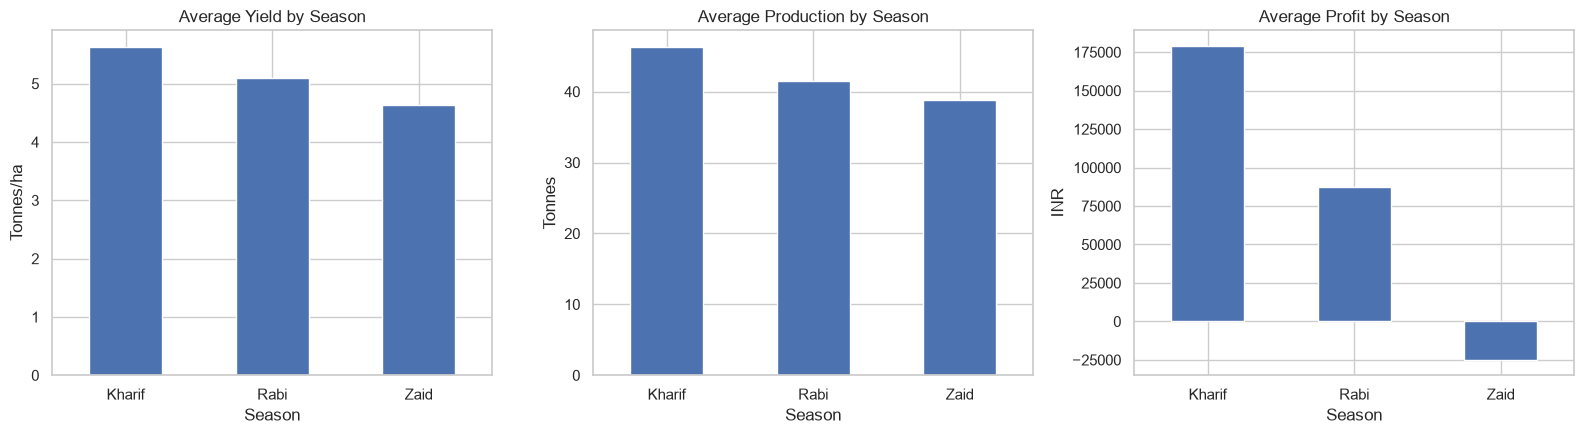

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

season_means["Yield_Tonnes_Ha"].plot(kind="bar", ax=axes[0], title="Average Yield by Season")
axes[0].set_ylabel("Tonnes/ha")
axes[0].tick_params(axis="x", rotation=0)

season_means["Production_Tonnes"].plot(kind="bar", ax=axes[1], title="Average Production by Season")
axes[1].set_ylabel("Tonnes")
axes[1].tick_params(axis="x", rotation=0)

season_means["Profit_INR"].plot(kind="bar", ax=axes[2], title="Average Profit by Season")
axes[2].set_ylabel("INR")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### Visualization Takeaway

The three panels make the seasonal performance gap visible: Kharif leads on average yield and profit, while Zaid trails on both measures.

## 7. 🌦️ Environmental Conditions by Season

### Analytical Questions

- How do rainfall, temperature, humidity, and sunlight vary across seasons?
- How does soil moisture vary across seasons?
- Are environmental conditions noticeably different between seasonal groups?

### Analysis

This section describes the environmental context surrounding the performance differences observed earlier.

In [77]:
environment = df.groupby("Season")[[
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_Moisture_pct"
]].mean().round(2)

display(environment)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


### Key Finding

- Kharif has the highest average rainfall (**852.11 mm**), humidity (**71.81%**), and soil moisture (**31.20%**).
- Zaid has the highest average temperature (**31.04°C**) and sunlight (**8.18 h/day**), but the lowest soil moisture (**19.17%**).

**Interpretation:** Environmental conditions differ noticeably across seasons and provide context for the seasonal performance comparisons.

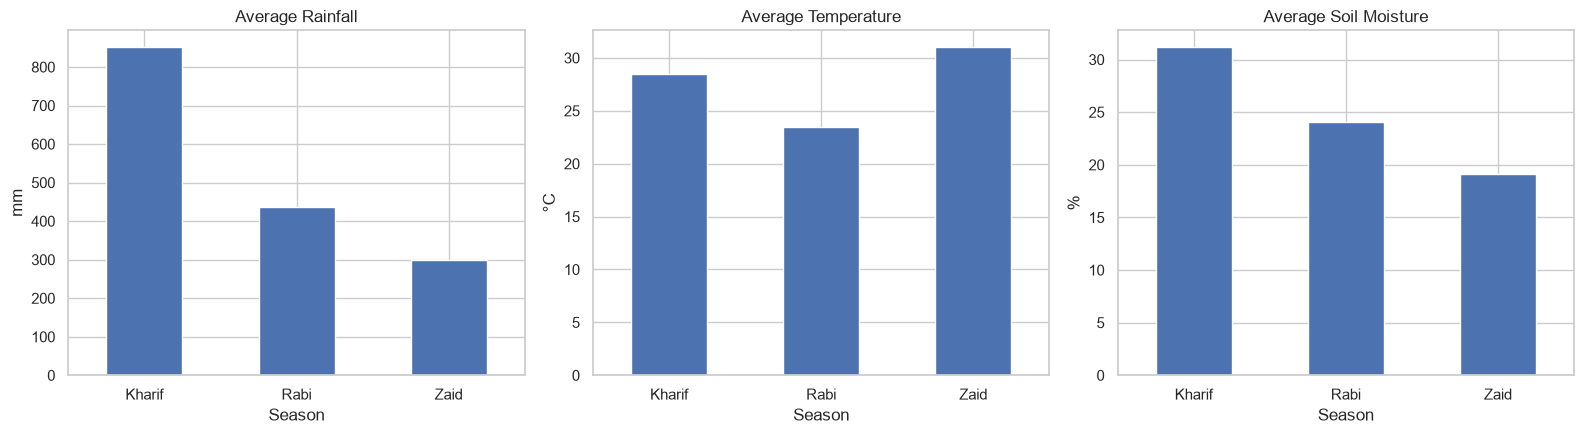

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
environment["Rainfall_mm"].plot(kind="bar", ax=axes[0], title="Average Rainfall")
axes[0].set_ylabel("mm")
axes[0].tick_params(axis="x", rotation=0)

environment["Avg_Temperature_C"].plot(kind="bar", ax=axes[1], title="Average Temperature")
axes[1].set_ylabel("°C")
axes[1].tick_params(axis="x", rotation=0)

environment["Soil_Moisture_pct"].plot(kind="bar", ax=axes[2], title="Average Soil Moisture")
axes[2].set_ylabel("%")
axes[2].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


### Visualization Takeaway

The environmental charts show clear seasonal separation, especially in rainfall and soil moisture, providing context for the observed performance differences.

## 8. 💧 Resource Usage and Irrigation

### Analytical Questions

- Are fertilizer, pesticide, and nutrient inputs different across seasons?
- How does water usage vary across seasons?
- How does water efficiency vary across seasons?
- How does irrigation-method distribution change by season?

### Analysis

Resource patterns are compared without assuming that a higher or lower input is automatically better.

In [79]:
resources = df.groupby("Season")[[
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Nitrogen_kg_ha",
    "Phosphorus_kg_ha", "Potassium_kg_ha", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]].mean().round(2)

display(resources)

irrigation_share = pd.crosstab(
    df["Season"], df["Irrigation_Method"], normalize="index"
).mul(100).round(2)

display(irrigation_share)


,Fertilizer_kg_ha,Pesticide_Litre_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,187.08,5.08,120.02,58.10,105.30,6102.20,5.89
Rabi,185.41,5.02,120.40,57.31,103.93,5846.99,5.19
Zaid,184.64,5.17,120.53,58.13,105.42,6419.89,4.41


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


### Key Finding

- Average water use is highest in Zaid (**6,419.89 m³**).
- Zaid also has the lowest water efficiency (**4.41 t/1,000 m³**).
- Irrigation shares are broadly similar across seasons, with Flood irrigation the largest category in each.

**Interpretation:** Water use and water efficiency do not move together in the same way across seasons, so both measures should be considered during planning.

## 9. 🌱 Crop and Season Analysis

### Analytical Questions

- Which crops perform best in each season?
- Are some crops particularly associated with certain seasons?
- Does the seasonal pattern remain similar across crops?

### Analysis

The crop-by-season yield matrix compares performance at a more detailed level than the overall seasonal averages.

In [80]:
crop_season_yield = df.pivot_table(
    index="Crop", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean"
)

display(crop_season_yield.round(2))


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.94
Groundnut,1.48,1.23,1.04
Maize,2.97,2.62,2.28
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.95,38.42
Wheat,2.25,2.06,1.75


### Key Finding

- Sugarcane has the highest average yield in every season: **53.46 t/ha** in Kharif, **43.95 t/ha** in Rabi, and **38.42 t/ha** in Zaid.
- For every listed crop, average yield is highest in Kharif and lowest in Zaid.

**Interpretation:** The crop-by-season results show a consistent seasonal ordering across the displayed crops, with Sugarcane having the highest average yield.

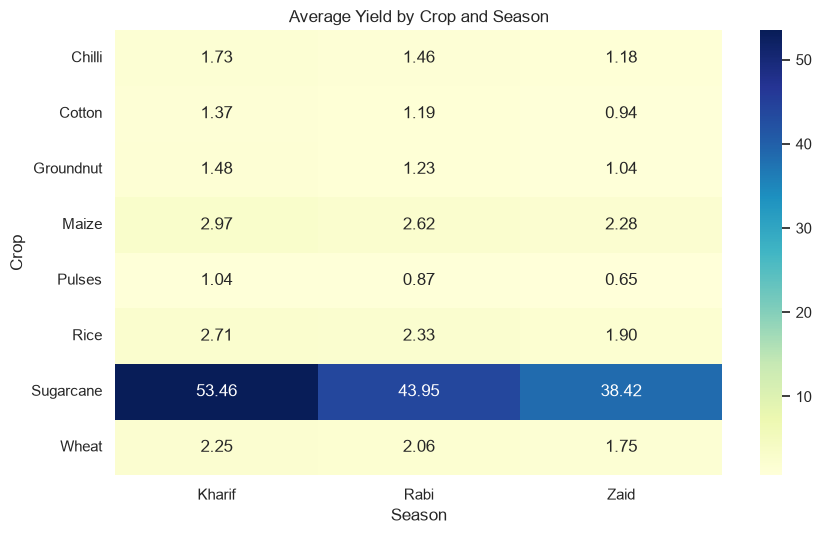

In [81]:
plt.figure(figsize=(9, 5.5))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


### Visualization Takeaway

The heatmap makes the crop-by-season pattern visible: the seasonal ordering is consistently **Kharif → Rabi → Zaid** across the displayed crops.

## 10. 💰 Economic Performance

### Analytical Questions

- How do market price, cost, revenue, and profit differ between seasons?
- Which crops have the highest and lowest average profit?
- Do economic outcomes follow the same pattern as yield?

### Analysis

Profitability is analyzed separately because strong production does not necessarily imply strong economic performance.

In [82]:
economic = df.groupby("Season")[[
    "Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR", "Profit_INR"
]].mean().round(2)

display(economic)


,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


### Key Finding

- Kharif has the highest average revenue (**₹710,719**) and profit (**₹178,915**).
- Zaid has the highest average cost (**₹543,977**) but negative average profit (**−₹24,805**).

**Interpretation:** Revenue and cost must be considered together when evaluating economic performance.

,Average Profit (INR)
Crop,
Sugarcane,817188.0
Chilli,750878.0
Cotton,124547.0
Groundnut,44858.0
Pulses,-4238.0
Maize,-83978.0
Rice,-102214.0
Wheat,-123398.0


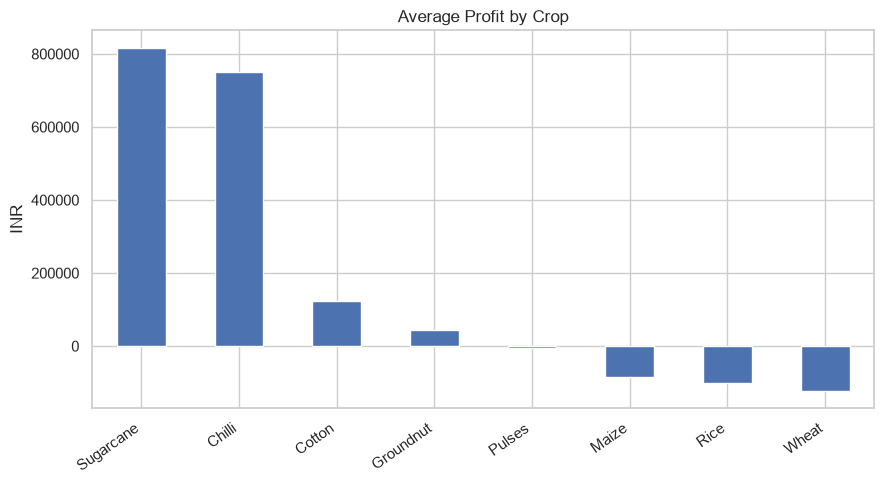

In [83]:
crop_profit = df.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)
display(crop_profit.round(0).to_frame("Average Profit (INR)"))

plt.figure(figsize=(9, 5))
crop_profit.plot(kind="bar")
plt.title("Average Profit by Crop")
plt.ylabel("INR")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### Key Finding

Average profit varies strongly by crop. Sugarcane and Chilli have the highest average profits in the dataset, while Wheat, Rice, and Maize show negative average profit.

**Interpretation:** Profitability differs across crop groups, so seasonal planning should not rely on yield alone.

## 11. Disease and Pest Risk

### Analytical Question

How does average disease and pest risk vary across seasons?

### Analysis

Risk is treated as an observed dataset measure. The analysis does not claim that season alone causes the observed risk level.

In [84]:
risk = df.groupby("Season")["Disease_Pest_Risk_pct"].mean().sort_values(ascending=False)
display(risk.round(2).to_frame("Average Risk (%)"))


,Average Risk (%)
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


### Key Finding

Average disease and pest risk is highest in **Kharif (54.47%)**, followed by Rabi (**40.48%**) and Zaid (**38.22%**).

**Interpretation:** The observed risk levels differ by season, but the comparison describes association rather than causation.

## 12. 📈 Correlation Analysis

### Analytical Questions

- Is there a relationship between environmental conditions and yield?
- Is water usage related to yield?
- Is water efficiency related to yield or profitability?
- Is farm area related to production?
- Which variables have the strongest relationship with yield?
- Which variables have the strongest relationship with profit?

### Analysis

Correlation measures association, **not causation**. The heatmap identifies relationships worth interpreting further.

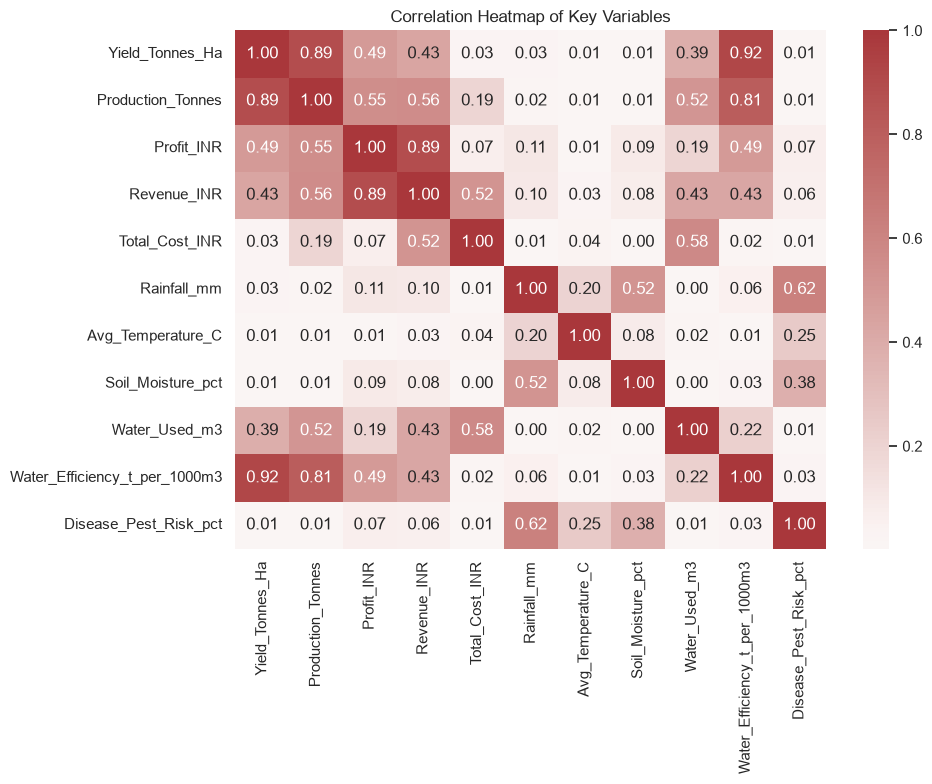

Top absolute correlations with Yield:


,Absolute correlation
Water_Efficiency_t_per_1000m3,0.915738
Production_Tonnes,0.885713
Profit_INR,0.489655
Revenue_INR,0.433389
Water_Used_m3,0.387414
Total_Cost_INR,0.031097


In [85]:
corr_cols = [
    "Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR", "Revenue_INR",
    "Total_Cost_INR", "Rainfall_mm", "Avg_Temperature_C",
    "Soil_Moisture_pct", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"
]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap of Key Variables")
plt.tight_layout()
plt.show()

print("Top absolute correlations with Yield:")
display(corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").abs().sort_values(ascending=False).head(6).to_frame("Absolute correlation"))


### Key Finding

The strongest absolute correlation with yield in the current analysis is **water efficiency (|r| ≈ 0.916)**, followed by production (**|r| ≈ 0.886**).

**Interpretation:** These are associations in the dataset, not causal effects. They identify relationships that may deserve further investigation.

## 12A. Targeted Relationships and Geographic Comparison

### Analytical Questions

- Is there a relationship between environmental conditions and yield?
- Is water usage related to yield?
- Is water efficiency related to yield or profitability?
- Is farm area related to production?
- Which factors have the strongest relationship with yield and profit?
- Are there meaningful differences between states and districts?
- Are seasonal patterns consistent across geographical areas?
- Are there unusual or unexpected observations?

### Analysis

This section consolidates questions that need more targeted comparisons than a general correlation heatmap.

In [86]:
# Targeted relationships, geographic comparison and unusual-observation checks

relationship_pairs = [
    ("Rainfall_mm", "Yield_Tonnes_Ha"),
    ("Avg_Temperature_C", "Yield_Tonnes_Ha"),
    ("Humidity_pct", "Yield_Tonnes_Ha"),
    ("Sunlight_Hours_Day", "Yield_Tonnes_Ha"),
    ("Soil_Moisture_pct", "Yield_Tonnes_Ha"),
    ("Water_Used_m3", "Yield_Tonnes_Ha"),
    ("Water_Efficiency_t_per_1000m3", "Yield_Tonnes_Ha"),
    ("Water_Efficiency_t_per_1000m3", "Profit_INR"),
    ("Farm_Area_Hectares", "Production_Tonnes"),
    ("Yield_Tonnes_Ha", "Profit_INR"),
]

relationship_table = pd.DataFrame([
    {
        "Variable 1": a,
        "Variable 2": b,
        "Pearson r": df[a].corr(df[b])
    }
    for a, b in relationship_pairs
]).sort_values("Pearson r", key=lambda s: s.abs(), ascending=False)

display(relationship_table.round(3))

state_summary = (
    df.groupby("State")[[
        "Yield_Tonnes_Ha",
        "Production_Tonnes",
        "Profit_INR",
        "Water_Efficiency_t_per_1000m3",
        "Disease_Pest_Risk_pct"
    ]]
    .mean()
    .sort_values("Yield_Tonnes_Ha", ascending=False)
    .round(2)
)

print("State-level performance summary:")
display(state_summary)

state_season_yield = df.pivot_table(
    index="State", columns="Season",
    values="Yield_Tonnes_Ha", aggfunc="mean"
).round(2)

print("Average yield by state and season:")
display(state_season_yield)

season_consistency = (
    state_season_yield.max(axis=1) - state_season_yield.min(axis=1)
).sort_values()

print("Smallest seasonal yield range across states:")
display(season_consistency.head(5).to_frame("Seasonal yield range (t/ha)"))

# Simple anomaly screen: flag the most extreme values in selected numeric metrics.
anomaly_cols = [
    "Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR",
    "Water_Used_m3", "Disease_Pest_Risk_pct"
]
z_scores = ((df[anomaly_cols] - df[anomaly_cols].mean()) /
            df[anomaly_cols].std(ddof=0)).abs()
anomaly_score = z_scores.mean(axis=1)

unusual = df.loc[anomaly_score.nlargest(5).index,
                 ["Farm_ID", "State", "District", "Crop", "Season"] + anomaly_cols].copy()
unusual["Composite extremeness score"] = anomaly_score.loc[unusual.index].round(2)

print("Top 5 records flagged by a composite extremeness screen:")
display(unusual.sort_values("Composite extremeness score", ascending=False).round(2))


,Variable 1,Variable 2,Pearson r
6,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha,0.916
9,Yield_Tonnes_Ha,Profit_INR,0.490
7,Water_Efficiency_t_per_1000m3,Profit_INR,0.489
5,Water_Used_m3,Yield_Tonnes_Ha,0.387
8,Farm_Area_Hectares,Production_Tonnes,0.198
0,Rainfall_mm,Yield_Tonnes_Ha,0.027
3,Sunlight_Hours_Day,Yield_Tonnes_Ha,-0.016
2,Humidity_pct,Yield_Tonnes_Ha,0.011
4,Soil_Moisture_pct,Yield_Tonnes_Ha,0.010
1,Avg_Temperature_C,Yield_Tonnes_Ha,0.009


State-level performance summary:


,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
State,,,,,
Punjab,6.12,52.23,136025.64,5.62,46.00
Gujarat,5.76,48.33,117568.24,5.58,45.95
Karnataka,5.75,47.73,119422.34,5.56,46.06
Telangana,5.05,39.25,108829.62,5.46,46.36
Maharashtra,5.01,43.98,135428.86,5.28,46.44
Madhya Pradesh,4.98,37.56,86840.76,5.27,47.08
Tamil Nadu,4.87,40.84,117744.75,5.31,46.28
Andhra Pradesh,4.63,36.91,73453.53,5.03,46.72


Average yield by state and season:


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.70,4.05
Karnataka,6.45,4.73,6.62
Madhya Pradesh,5.99,3.75,5.46
Maharashtra,5.43,5.50,2.26
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.49,4.10
Telangana,5.55,4.82,4.24


Smallest seasonal yield range across states:


,Seasonal yield range (t/ha)
State,
Telangana,1.31
Tamil Nadu,1.42
Karnataka,1.89
Andhra Pradesh,2.21
Madhya Pradesh,2.24


Top 5 records flagged by a composite extremeness screen:


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct,Composite extremeness score
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,1424.40,3330582,23289,42.7,5.39
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,82.68,1154.21,3740099,23472,64.6,5.16
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,1249.21,3378879,23936,43.8,4.98
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,79.25,1122.18,3232970,21133,41.8,4.57
1194,SF11195,Madhya Pradesh,Warangal,Sugarcane,Kharif,66.24,948.56,2539590,24373,85.5,4.52


### Key Finding

This targeted section separates **association**, geographic comparison, and unusual-observation screening from the broader seasonal analysis.

**Interpretation:** The tables support comparison and prioritization for further investigation; they do not establish that one factor causes another.

### Average Yield by State and Season

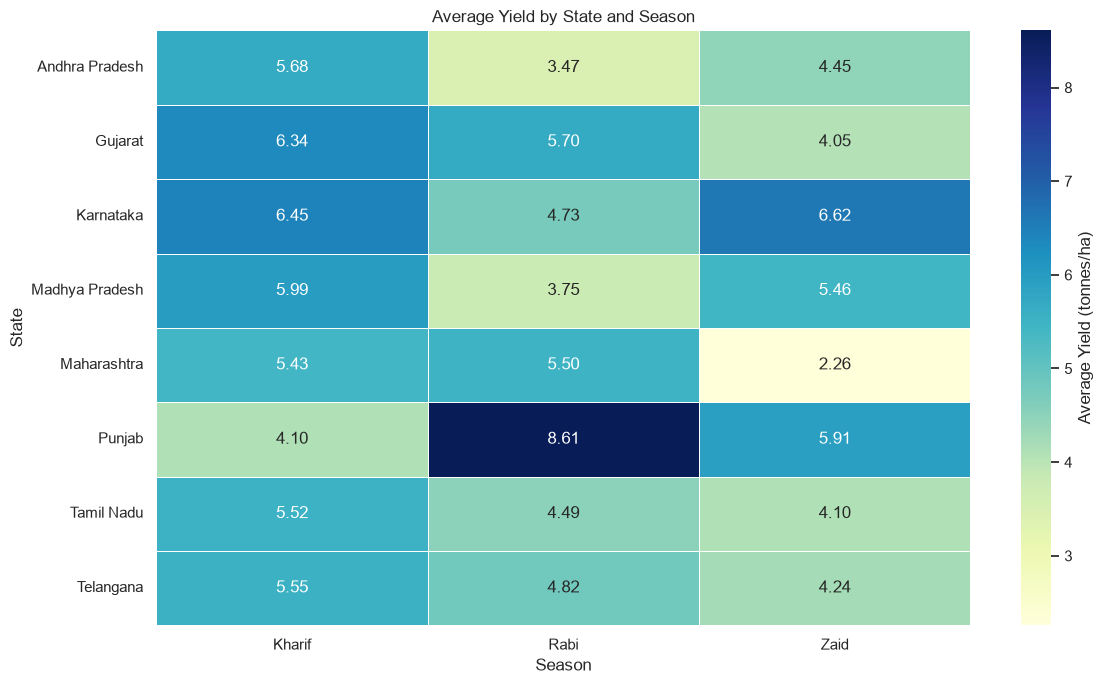

In [87]:
state_season_yield_heatmap = df.pivot_table(
    index="State",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
)

plt.figure(figsize=(12, 7))
sns.heatmap(
    state_season_yield_heatmap,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Average Yield (tonnes/ha)"}
)
plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()


### Visualization Takeaway

The heatmap shows that seasonal performance varies across states: Punjab records a notably high Rabi yield of 8.61 t/ha, Karnataka has a relatively high Zaid yield of 6.62 t/ha, and Maharashtra has a comparatively low Zaid yield of 2.26 t/ha. These differences indicate that the seasonal pattern is not identical across all geographic areas and describe observed variation rather than causation.

## 13. Statistical Analysis

### Analytical Question

Are the observed seasonal differences statistically meaningful for key performance measures?

### Analysis

One-way ANOVA is applied to selected continuous metrics to test whether seasonal group means differ. A small p-value provides evidence of a difference among group means; it does **not** establish causation.

In [88]:
anova_results = {}
for metric in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3"]:
    result = one_way_anova(df, metric)
    anova_results[metric] = {"F-statistic": result.statistic, "p-value": result.pvalue}

anova_table = pd.DataFrame(anova_results).T
display(anova_table)

print("Interpretation:")
print("A small p-value indicates evidence of differences among seasonal group means for that metric.")
print("ANOVA identifies group differences; it does not establish causation.")


,F-statistic,p-value
Yield_Tonnes_Ha,1.462947,2.316769e-01
Profit_INR,34.291750,1.712416e-15
Water_Efficiency_t_per_1000m3,6.948270,9.719377e-04


Interpretation:
A small p-value indicates evidence of differences among seasonal group means for that metric.
ANOVA identifies group differences; it does not establish causation.


### Key Finding

ANOVA provides evidence of seasonal mean differences for **profit** (p ≈ 1.71 × 10⁻¹⁵) and **water efficiency** (p ≈ 9.72 × 10⁻⁴). Yield does not show a statistically significant seasonal mean difference at the 5% level (p ≈ 0.232).

**Interpretation:** The tests support differences in profit and water efficiency among seasonal groups, while the yield result does not meet the selected significance threshold.

## 14. 💡 Key Findings

### Analytical Questions

- What are the strongest evidence-based findings?
- What are the most important seasonal differences?
- Which patterns deserve attention?

### Analysis

The findings below are calculated directly from the cleaned dataset and focus on the strongest observations rather than listing every possible statistic.

In [89]:
best_yield_season = season_means["Yield_Tonnes_Ha"].idxmax()
worst_yield_season = season_means["Yield_Tonnes_Ha"].idxmin()
best_profit_season = season_means["Profit_INR"].idxmax()
worst_profit_season = season_means["Profit_INR"].idxmin()
best_efficiency_season = season_means["Water_Efficiency_t_per_1000m3"].idxmax()
highest_risk_season = season_means["Disease_Pest_Risk_pct"].idxmax()

print(f"Highest average yield: {best_yield_season} ({season_means.loc[best_yield_season, 'Yield_Tonnes_Ha']:.2f} t/ha)")
print(f"Lowest average yield: {worst_yield_season} ({season_means.loc[worst_yield_season, 'Yield_Tonnes_Ha']:.2f} t/ha)")
print(f"Highest average profit: {best_profit_season} (₹{season_means.loc[best_profit_season, 'Profit_INR']:,.0f})")
print(f"Lowest average profit: {worst_profit_season} (₹{season_means.loc[worst_profit_season, 'Profit_INR']:,.0f})")
print(f"Highest water efficiency: {best_efficiency_season} ({season_means.loc[best_efficiency_season, 'Water_Efficiency_t_per_1000m3']:.2f} t/1,000 m³)")
print(f"Highest disease/pest risk: {highest_risk_season} ({season_means.loc[highest_risk_season, 'Disease_Pest_Risk_pct']:.2f}%)")


Highest average yield: Kharif (5.63 t/ha)
Lowest average yield: Zaid (4.63 t/ha)
Highest average profit: Kharif (₹178,915)
Lowest average profit: Zaid (₹-24,805)
Highest water efficiency: Kharif (5.89 t/1,000 m³)
Highest disease/pest risk: Kharif (54.47%)


### Visualization Takeaway

The seasonal performance gap is visible in the comparison panels: Kharif leads on average yield and profit, while Zaid trails on both measures.

## 15. ✅ Recommendations

### Analytical Question

What practical recommendations can reasonably be derived from the observed evidence?

### Analysis

Recommendations are kept separate from raw findings. They are data-informed planning considerations, not unsupported claims of causation.

### Recommendations

1. Consider seasonal crop planning based on the observed yield and profitability patterns.
2. Monitor water efficiency alongside water use when comparing seasons.
3. Investigate crop-specific differences before making resource allocation decisions.
4. Treat the observed Kharif disease and pest risk as a priority for monitoring and further investigation.
5. Use geographic comparisons to identify locations that may benefit from more detailed follow-up.

**Interpretation:** These recommendations translate the observed associations and group differences into practical areas for planning and further analysis.

## 16. 🏁 Conclusion

### Analytical Questions

- What conclusions can reasonably be drawn from the available data?
- How can the findings support better seasonal agricultural planning?

### Conclusion

This notebook completes the workflow from data loading and quality checks through analysis, visualization, statistical evidence, findings, and recommendations.

The analysis connects seasonal conditions with measurable agricultural, resource, and economic outcomes using evidence from the dataset. The results describe observed patterns and associations; they do not establish causation.